# Optional project resource · Spatial payoffs and copying rules

<span class="workshop-download-enabled" aria-hidden="true"></span>


# Context

Changing T alters the incentive to defect. Changing the copying rule alters how agents respond to scores. These are different changes, even with the same network and starting population.

The game specifies payoffs, not behaviour. Here agents copy actions; they do not solve a Nash-equilibrium problem or remember earlier encounters. For strategies with memory, see the optional [Axelrod tournament](Axelrod_tournament.ipynb).

# Specify the model

| Ingredient | Fixed baseline |
|---|---|
| State | one action per agent: cooperate (C) or defect (D) |
| World | 24 × 24 periodic square; four neighbours per agent; no payoff self-interactions |
| Payoffs | mutual C: 3 each; mutual D: 1 each; lone defector: T = 3.4; lone cooperator: 0 |
| Initialisation | exactly half C; positions shuffled reproducibly |
| Scoring | sum four pairwise payoffs, all from the current state |
| Behaviour | copy the highest-scoring candidate among self and four neighbours |
| Ties | choose uniformly among maximum-score candidates |
| Timing | calculate every decision from the old state, then update together |
| Budget | 160 updates; record generation zero |
| Measurements | fraction cooperating through time; mean over the final 40 recorded updates |

The payoff ordering is a strict PD: T > 3 > 1 > 0. Scores are reset each update; agents store neither match histories nor lifetime scores. Including self as a copying candidate is not playing a game against oneself. With no mutation, all-C and all-D populations cannot create a missing action.

This is a small course model, not an empirical model of human behaviour or an exact reproduction of [The Prisoner's Kaleidoscope](https://www.complexity-explorables.org/explorables/prisoners-kaleidoscope/), which uses a different neighbourhood and includes payoff self-interaction.

# One population

The next cell defines the model and shows an animation beside its cooperation trace. Expand the code to inspect it. This single run illustrates the process; it does not establish a general outcome.

In [1]:
"""Small networked PD laboratory: payoffs fixed, behavioural rules replaceable."""
import numpy as np

C, D = 0, 1


def lattice(side):
    """Four distinct neighbours on a periodic square; no self-interactions."""
    if side < 3:
        raise ValueError('Use side >= 3.')
    ids = np.arange(side * side).reshape(side, side)
    return np.stack([np.roll(ids, 1, 0), np.roll(ids, -1, 0),
                     np.roll(ids, 1, 1), np.roll(ids, -1, 1)], axis=-1).reshape(-1, 4)


def payoff_matrix(temptation=3.4):
    """Rows are own action, columns opponent: C=0, D=1."""
    if temptation <= 3:
        raise ValueError('Strict PD requires T > R=3 > P=1 > S=0.')
    return np.array([[3., 0.], [float(temptation), 1.]])


def scores(state, neighbours, payoffs):
    return payoffs[state[:, None], state[neighbours]].sum(axis=1)


def copy_best(state, totals, neighbours, rng):
    """Copy a maximum-score candidate, including self; break ties uniformly."""
    candidates = np.column_stack([np.arange(len(state)), neighbours])
    values = totals[candidates]
    tied = values == values.max(axis=1, keepdims=True)
    chosen = np.argmax(np.where(tied, rng.random(tied.shape), -1), axis=1)
    return state[candidates[np.arange(len(state)), chosen]].copy()


def copy_one_reference(state, totals, neighbours, rng):
    """Sample one neighbour; copy only if strictly better; ties keep the current action."""
    selected = neighbours[np.arange(len(state)), rng.integers(neighbours.shape[1], size=len(state))]
    return np.where(totals[selected] > totals, state[selected], state).copy()


def initial_state(side=24, fraction_c=0.5, seed=0):
    """Same exact initial C count in each run, independently shuffled positions."""
    if not 0 <= fraction_c <= 1:
        raise ValueError('fraction_c must be in [0, 1].')
    state = np.full(side * side, D, dtype=int)
    state[:round(fraction_c * len(state))] = C
    np.random.default_rng(seed).shuffle(state)
    return state


def simulate(initial, neighbours, rule=copy_best, temptation=3.4, steps=160, seed=1000):
    """Every score and decision uses the same old state; record generation zero."""
    state = np.array(initial, dtype=int, copy=True)
    rng = np.random.default_rng(seed)
    payoffs = payoff_matrix(temptation)
    history = [state.copy()]
    for _ in range(steps):
        totals = scores(state, neighbours, payoffs)
        state = np.asarray(rule(state, totals, neighbours, rng), dtype=int)
        if state.shape != history[0].shape or not np.isin(state, [C, D]).all():
            raise ValueError('The rule must return one C/D action for each agent.')
        history.append(state.copy())
    return np.array(history)


def experiment(rule, temptation=3.4, side=24, steps=160, repeats=12, root_seed=3024):
    """Matched initial configurations across conditions; reproducible update streams."""
    neighbours = lattice(side)
    histories = []
    for run in range(repeats):
        initial = initial_state(side, seed=root_seed + run)
        history = simulate(initial, neighbours, rule, temptation, steps,
                           seed=root_seed + 10000 + run)
        histories.append((history == C).mean(axis=1))
    return np.array(histories)


import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

try:
    from tools.figure_style import (
        INK, BLUE, ORANGE, apply_course_figure_style, style_animation_frame
    )
except ModuleNotFoundError:  # Keep a downloaded standalone notebook runnable.
    INK, BLUE, ORANGE = '#1B2A4C', '#2C7FB8', '#D95F3B'
    def apply_course_figure_style():
        plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                             'axes.spines.right': False, 'axes.labelcolor': INK,
                             'text.color': INK, 'font.family': 'DejaVu Sans',
                             'font.size': 10})
    def style_animation_frame(fig, axes=None):
        apply_course_figure_style()
        for ax in (axes if axes is not None else fig.axes):
            if ax.name == 'rectilinear':
                ax.spines[['top', 'right']].set_visible(False)

apply_course_figure_style()
SIDE, STEPS, REPEATS = 24, 160, 12
neighbours = lattice(SIDE)
baseline = simulate(initial_state(SIDE, seed=3024), neighbours, steps=STEPS)
cooperation = (baseline == C).mean(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), constrained_layout=True)
picture = axes[0].imshow(baseline[0].reshape(SIDE, SIDE), cmap=ListedColormap([BLUE, ORANGE]), vmin=0, vmax=1)
axes[0].set(xticks=[], yticks=[], title='Blue: cooperate; orange: defect')
axes[1].plot(np.arange(STEPS+1), cooperation, color=INK)
cursor = axes[1].axvline(0, color=ORANGE)
axes[1].set(xlabel='Population update', ylabel='Fraction cooperating', ylim=(-.03, 1.03))
def draw(frame):
    picture.set_data(baseline[frame].reshape(SIDE, SIDE))
    cursor.set_xdata([frame, frame])
    axes[0].set_xlabel(f'Update {frame}')
    style_animation_frame(fig, axes)
    return picture, cursor
animation = FuncAnimation(fig, draw, frames=list(range(0, STEPS+1, 4)), interval=160)
display(HTML(animation.to_jshtml()))
plt.close(fig)
print('Baseline uses highest-score copying, including uniform tie-breaking.')

Baseline uses highest-score copying, including uniform tie-breaking.


# Check one update

The supplied check uses a 5 × 5 world with one central defector. Its score is 13.6; adjacent cooperators score 9 and distant cooperators score 12. After one highest-score-copying update, the four adjacent agents also defect.

`payoff_matrix` defines the game, `scores` adds encounter payoffs, the copying rule proposes actions, and `simulate` updates the population. Every decision uses the old state. The checks also confirm that all-C and all-D populations remain unchanged.

In [2]:
small_network = lattice(5)
small = np.full(25, C); small[12] = D
totals = scores(small, small_network, payoff_matrix())
assert np.isclose(totals[12], 13.6)
assert np.all(totals[small_network[12]] == 9)
after = copy_best(small, totals, small_network, np.random.default_rng(0))
assert set(np.flatnonzero(after == D)) == {12, *small_network[12]}
for action, expected in [(C, 12), (D, 4)]:
    homogeneous = np.full(25, action)
    assert np.all(scores(homogeneous, small_network, payoff_matrix()) == expected)
    assert np.all(simulate(homogeneous, small_network, steps=4) == action)
print('Checks passed. Centre score: 13.6; adjacent C: 9; distant C: 12.')
print('After one update (C=0, D=1):')
print(after.reshape(5, 5))

Checks passed. Centre score: 13.6; adjacent C: 9; distant C: 12.
After one update (C=0, D=1):
[[0 0 0 0 0]
 [0 0 1 0 0]
 [0 1 1 1 0]
 [0 0 1 0 0]
 [0 0 0 0 0]]


# Change the payoff parameter

The next experiment keeps the copying rule fixed and compares T = 3.2, 3.4 and 3.8. Each condition uses the same 12 initial configurations and 160 updates. All three payoff matrices satisfy the strict Prisoner's Dilemma ordering.

The curves show the median cooperation fraction; the bands show the middle 50% of runs, not confidence intervals. Similar results across these values do not show that changing the copying rule will also leave the result unchanged.

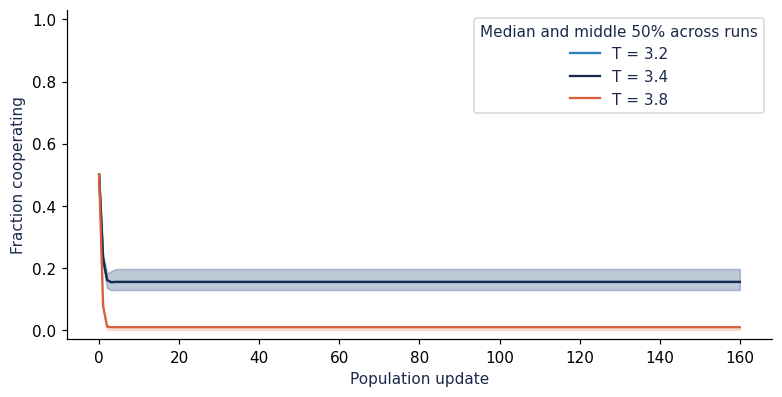

Payoff comparison uses the same copying rule at T = 3.2, 3.4 and 3.8.


In [3]:
def plot_ensemble(ax, traces, label, colour):
    q25, median, q75 = np.quantile(traces, [.25, .5, .75], axis=0)
    updates = np.arange(traces.shape[1])
    ax.plot(updates, median, label=label, color=colour)
    ax.fill_between(updates, q25, q75, color=colour, alpha=.16)
    ax.set(xlabel='Population update', ylabel='Fraction cooperating', ylim=(-.03, 1.03))

parameter_results = {t: experiment(copy_best, t, SIDE, STEPS, REPEATS) for t in [3.2, 3.4, 3.8]}
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
for (t, traces), colour in zip(parameter_results.items(), [BLUE, INK, ORANGE]):
    plot_ensemble(ax, traces, f'T = {t}', colour)
ax.legend(title='Median and middle 50% across runs')
plt.show()
print('Payoff comparison uses the same copying rule at T = 3.2, 3.4 and 3.8.')

# Change the copying rule

The alternative rule samples one neighbour instead of finding the highest scorer:

```text
FOR each agent:
    sample one of its four neighbours uniformly
    if that neighbour scored strictly higher, copy its action
    otherwise keep the current action
RETURN all proposed actions together
```

The baseline compares self and four neighbours, choosing randomly among tied highest scorers. The alternative samples one neighbour and keeps its action on a tie. This comparison changes the whole copying policy, including tie handling, while keeping payoffs fixed.

The supplied `copy_one_reference` makes the comparison runnable. Optionally implement the rule in `copy_one_student` and set `USE_REFERENCE_RULE = False`. `state` holds actions, `totals` holds scores and `neighbours` lists contacts. Use `rng` for random choices and return a new action array without altering the inputs.

In [4]:
def copy_one_student(state, totals, neighbours, rng):
    # Optional: implement the sampled-comparison policy above.
    raise NotImplementedError('Implement the rule, or keep USE_REFERENCE_RULE=True below.')

# The supplied rule runs by default. Switch to False only to test your implementation.
USE_REFERENCE_RULE = True
comparison_rule = copy_one_reference if USE_REFERENCE_RULE else copy_one_student
print('Using the supplied reference rule.' if USE_REFERENCE_RULE else 'Using your rule.')

Using the supplied reference rule.


````{dropdown} Optional detail: supplied copying rule
`copy_one_reference` uses:

```python
selected = neighbours[np.arange(len(state)),
                      rng.integers(neighbours.shape[1], size=len(state))]
return np.where(totals[selected] > totals, state[selected], state).copy()
```

Each agent samples a neighbour uniformly. `np.where` copies only when the neighbour scores strictly higher. Ties keep the current action, and the input arrays are unchanged.

Correct implementations may use random numbers differently and need not produce identical trajectories. The checks below test tie handling, output shape, unchanged inputs and homogeneous populations.
````

In [5]:
test_state = initial_state(5, seed=1)
unchanged = test_state.copy()
result = comparison_rule(test_state, np.ones(25), lattice(5), np.random.default_rng(7))
assert np.array_equal(result, test_state), 'On equal scores the sampled rule should keep all actions.'
assert np.array_equal(test_state, unchanged), 'Do not modify the input state.'
assert result.shape == test_state.shape and np.isin(result, [C, D]).all()
for action in [C, D]:
    h = simulate(np.full(25, action), lattice(5), comparison_rule, steps=4)
    assert np.all(h == action)
print('Selected-rule checks passed. Passing these checks is necessary, not proof of complete correctness.')

Selected-rule checks passed. Passing these checks is necessary, not proof of complete correctness.


# Compare the two rules

Both rules use T = 3.4, the same network, population size, initial configurations and 160 synchronous updates. Random updates are reproducible, but the same seed does not mean identical decisions under different rules.

The left plot shows cooperation through time. The right plot shows each run's mean over the final 40 updates; lines join matched initial configurations. This finite-window measure does not establish equilibrium or indefinite survival.

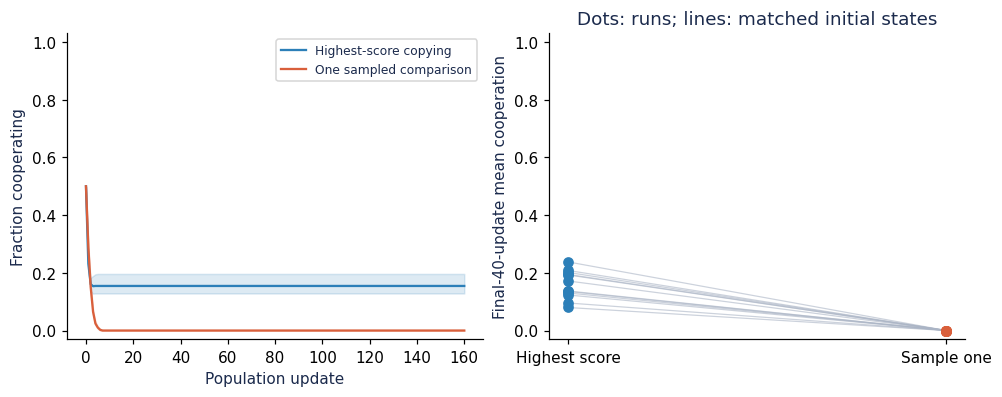

Median paired difference (sampled minus highest-score): -0.1545138888888889


In [6]:
best = parameter_results[3.4]
sampled = experiment(comparison_rule, 3.4, SIDE, STEPS, REPEATS)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
plot_ensemble(axes[0], best, 'Highest-score copying', BLUE)
plot_ensemble(axes[0], sampled, 'One sampled comparison', ORANGE)
axes[0].legend(fontsize=8)
late = np.column_stack([best[:, -40:].mean(axis=1), sampled[:, -40:].mean(axis=1)])
for pair in late:
    axes[1].plot([0, 1], pair, color='#AAB4C5', alpha=.6, linewidth=.8)
axes[1].scatter(np.zeros(REPEATS), late[:, 0], color=BLUE, zorder=3)
axes[1].scatter(np.ones(REPEATS), late[:, 1], color=ORANGE, zorder=3)
axes[1].set(xticks=[0, 1], xticklabels=['Highest score', 'Sample one'],
            ylabel='Final-40-update mean cooperation', ylim=(-.03, 1.03))
axes[1].set_title('Dots: runs; lines: matched initial states')
plt.show()
print('Median paired difference (sampled minus highest-score):', np.median(late[:, 1]-late[:, 0]))

## Reading the results

Changing T can leave trajectories unchanged when it leaves the ranking of scores unchanged. A different copying rule can change the speed of the process, the final-window cooperation level, or both. The full traces help distinguish these effects.

Agreement between these two rules supports only this tested comparison. Neither agreement nor a patterned image validates a model of real behaviour.

# Using this in a project

Possible uses, if relevant to your project:

- Check another population size, longer run or measurement window.
- Align tie handling across the two policies to investigate its contribution.
- Compare a fixed behavioural assumption with a plausible alternative while keeping other settings unchanged.

The practice questions on repeated games, populations and evolutionary change provide the conceptual background for this resource.